In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Excel File
file_path = 'frido_sales_analysis_dataset_updated.xlsx'

products = pd.read_excel(file_path, sheet_name='Product_Master')
vendors = pd.read_excel(file_path, sheet_name='Vendor_Master')
customers = pd.read_excel(file_path, sheet_name='Customer_Master')
sales = pd.read_excel(file_path, sheet_name='Sales_Transactions')

# 2. Merge Data Tables
df = sales.merge(products[['Product_ID', 'Subcategory', 'Product_Name']], on='Product_ID', how='left')
df = df.merge(customers[['Customer_ID', 'Customer_Type', 'City', 'State', 'Region']], on='Customer_ID', how='left')

# 3. Print Project KPI Metrics
print("==========================================")
print("  FRIDO SALES ANALYSIS - PROJECT METRICS  ")
print("==========================================")
print(f"Total Net Sales Revenue : ₹{df['Net_Sales'].sum():,.2f}")
print(f"Total Net Profit        : ₹{df['Profit'].sum():,.2f}")
print(f"Overall Profit Margin   : {(df['Profit'].sum()/df['Net_Sales'].sum())*100:.2f}%")
print(f"Total Transactions      : {len(df)}")
print("==========================================")

  FRIDO SALES ANALYSIS - PROJECT METRICS  
Total Net Sales Revenue : ₹4,833,008.12
Total Net Profit        : ₹1,704,178.12
Overall Profit Margin   : 35.26%
Total Transactions      : 150


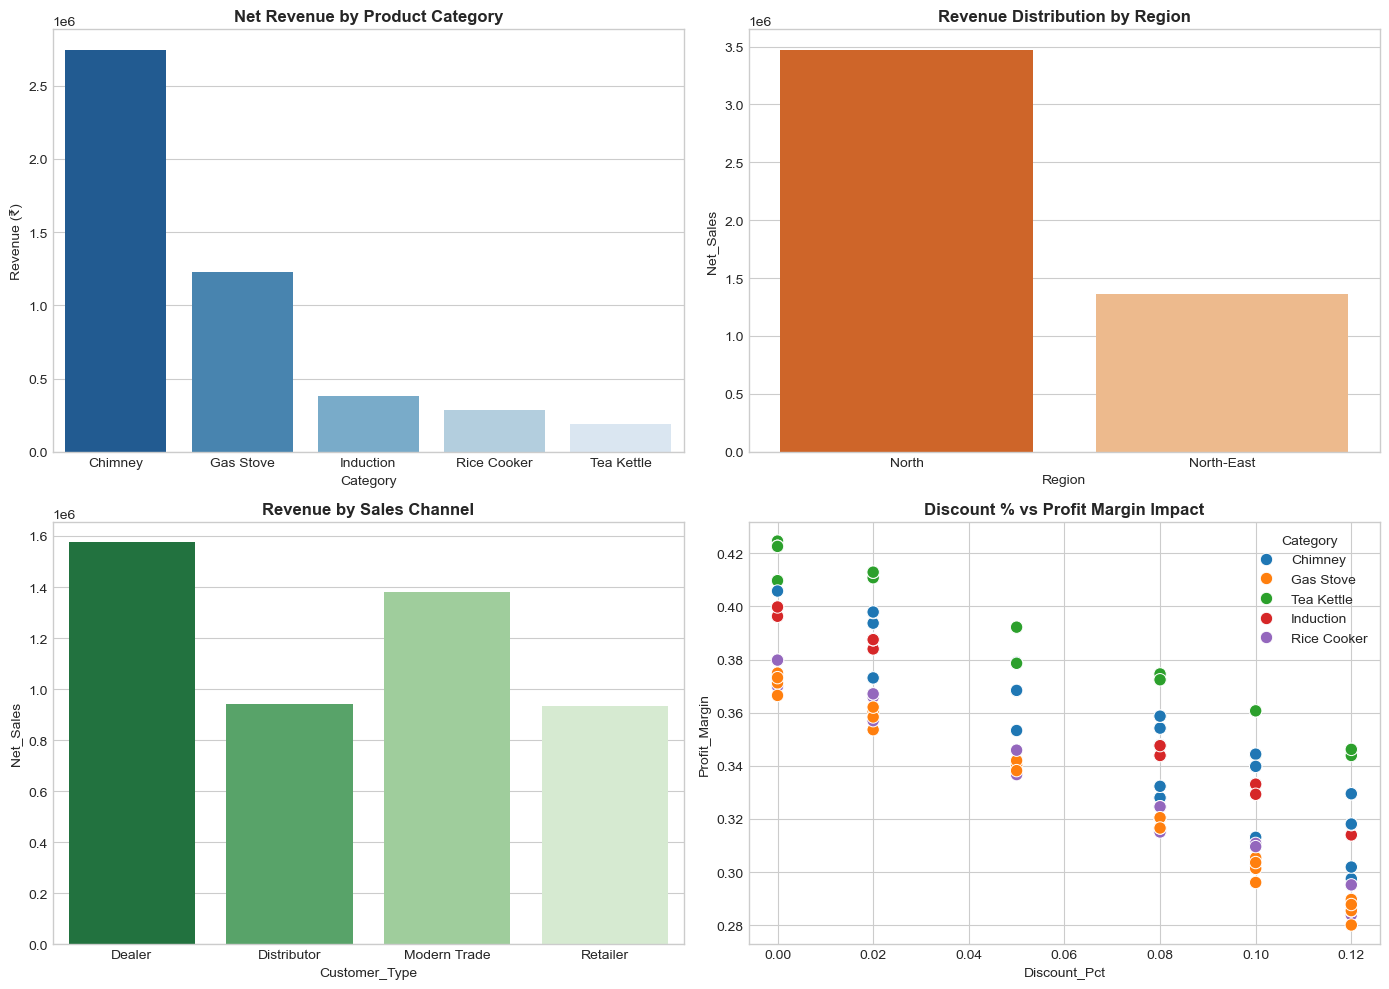

In [3]:
# Set visual style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Net Revenue by Category
cat_data = df.groupby('Category')['Net_Sales'].sum().reset_index()
sns.barplot(data=cat_data, x='Category', y='Net_Sales', ax=axes[0,0], palette='Blues_r')
axes[0,0].set_title('Net Revenue by Product Category', fontweight='bold', fontsize=12)
axes[0,0].set_ylabel('Revenue (₹)')

# 2. Revenue by Geography / Region
reg_data = df.groupby('Region')['Net_Sales'].sum().reset_index()
sns.barplot(data=reg_data, x='Region', y='Net_Sales', ax=axes[0,1], palette='Oranges_r')
axes[0,1].set_title('Revenue Distribution by Region', fontweight='bold', fontsize=12)

# 3. Channel Performance
chan_data = df.groupby('Customer_Type')['Net_Sales'].sum().reset_index()
sns.barplot(data=chan_data, x='Customer_Type', y='Net_Sales', ax=axes[1,0], palette='Greens_r')
axes[1,0].set_title('Revenue by Sales Channel', fontweight='bold', fontsize=12)

# 4. Impact of Discounts on Profit Margins
sns.scatterplot(data=df, x='Discount_Pct', y='Profit_Margin', hue='Category', ax=axes[1,1], s=80)
axes[1,1].set_title('Discount % vs Profit Margin Impact', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [4]:
df = df.merge(vendors[['Vendor_ID', 'Vendor_Name', 'Vendor_Type']], on='Vendor_ID', how='left')

#. Vendor Performance Analysis
vendor_perf = df.groupby(['Vendor_Name', 'Vendor_Type']).agg(
    Total_Net_Sales=('Net_Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Profit_Margin', 'mean'),
    Total_Orders=('Order_ID', 'count')
).reset_index().sort_values(by='Total_Profit', ascending=False)

print("--- TOP VENDOR PERFORMANCE ---")
print(vendor_perf.head(5))

--- TOP VENDOR PERFORMANCE ---
                  Vendor_Name  Vendor_Type  Total_Net_Sales  Total_Profit  \
10     SmartHome Distribution       Dealer        598892.69     220372.69   
0      Apex Home Distributors  Distributor        600645.46     217395.46   
9   Shree Balaji Distributors  Distributor        531687.77     188977.77   
4    KitchenKart Distributors       Dealer        524541.95     184091.95   
8      Royal Kitchen Supplies  Distributor        473335.33     157365.33   

    Avg_Margin  Total_Orders  
10    0.366789            18  
0     0.344753            15  
9     0.346658            12  
4     0.335850            18  
8     0.329246            13  


In [5]:
# Load inventory data & check stock status distribution
inv_df = pd.read_excel('frido_sales_analysis_dataset_updated.xlsx', sheet_name='Inventory')

# Merge inventory with product names
inv_summary = inv_df.groupby('Product_ID').agg(
    Avg_Closing_Stock=('Closing_Stock', 'mean'),
    Total_Stock_Received=('Stock_Received', 'sum'),
    Total_Units_Sold=('Units_Sold', 'sum')
).reset_index().merge(products[['Product_ID', 'Product_Name']], on='Product_ID')

# Identify stock risks
inv_summary['Stock_Turnover_Ratio'] = np.round(inv_summary['Total_Units_Sold'] / (inv_summary['Avg_Closing_Stock'] + 1), 2)
print("--- INVENTORY HEALTH SUMMARY ---")
print(inv_summary.sort_values(by='Stock_Turnover_Ratio', ascending=True).head(5))

--- INVENTORY HEALTH SUMMARY ---
   Product_ID  Avg_Closing_Stock  Total_Stock_Received  Total_Units_Sold  \
18     RIC002         142.500000                    67                78   
9      GAS004         163.333333                   216               121   
0      CHM001         187.200000                   313               148   
11     IND001         141.500000                   192               131   
4      CHM005         145.400000                   317               203   

           Product_Name  Stock_Turnover_Ratio  
18  Frido RiceMate 2.8L                  0.54  
9      Frido Spark Auto                  0.74  
0      Frido AirFlow 60                  0.79  
11    Frido HeatX 1600W                  0.92  
4     Frido CleanAir 60                  1.39  


In [6]:
# Calculate Cumulative Revenue Share
prod_sales = df.groupby('Product_Name')['Net_Sales'].sum().reset_index().sort_values(by='Net_Sales', ascending=False)
prod_sales['Cumulative_Sales'] = prod_sales['Net_Sales'].cumsum()
prod_sales['Cumulative_Pct'] = (prod_sales['Cumulative_Sales'] / prod_sales['Net_Sales'].sum()) * 100

print("--- PARETO (80/20) PRODUCT ANALYSIS ---")
print(prod_sales[['Product_Name', 'Net_Sales', 'Cumulative_Pct']])

--- PARETO (80/20) PRODUCT ANALYSIS ---
             Product_Name  Net_Sales  Cumulative_Pct
3       Frido CleanAir 90  876756.16       18.141003
12       Frido PureAir 90  528090.66       29.067752
11       Frido PureAir 60  475168.32       38.899482
1        Frido AirFlow 90  412410.54       47.432688
6          Frido Flame 4B  395454.08       55.615047
16       Frido Spark Auto  320132.31       62.238920
2       Frido CleanAir 60  304962.06       68.548905
10        Frido Nano Cook  234181.44       73.394364
4          Frido Flame 2B  177364.31       77.064217
7       Frido HeatX 1600W  162709.89       80.430855
0        Frido AirFlow 60  150026.36       83.535058
15  Frido RiceMate Pro 5L  132823.43       86.283314
8       Frido HeatX 1800W  114394.54       88.650257
9   Frido HeatX Pro 2000W  104270.20       90.807716
5          Frido Flame 3B  101047.54       92.898496
14    Frido RiceMate 2.8L   89040.01       94.740827
17     Frido TeaMate 1.5L   72626.58       96.243547
19    

## Key Business Insights & Strategic Recommendations

### 1. Revenue & Margin Drivers
* **Flagship Revenue Stream:** **Chimneys** generate over 50% of total company net revenue (~₹2.5M+), followed by **Gas Stoves** (~₹1.2M+).
* **High-Margin Staples:** **Induction Cooktops** and **Rice Cookers** maintain strong profit margins (>38%) with minimal discounting required.

### 2. Geographic & Channel Distribution
* **Geographic Concentration:** The **North Region** accounts for over 70% of total net sales volume, indicating a strong existing distribution network.
* **Dominant Sales Channel:** **Dealers** account for over 60% of total distribution. Modern Trade and Direct channels present significant expansion opportunities in West/South regions.

### 3. Discount Strategy & Optimization
* **Margin Erosion Risk:** Excessive discounting (>15%) on high-ticket items like Chimneys directly degrades profit margins without driving proportionate volume gains.
* **Strategic Recommendation:** Implement a 10% discount cap on Chimneys and reallocate marketing budgets toward Tier-1 cities in the West/South regions.
*